# 4. MD Trajectory Analysis 

## 4.1 RMSD and Distance Visualization

This notebook visualizes the results from Molecular Dynamics simulations of chalcone-FRD complexes:

- **RMSD (Root Mean Square Deviation)**: Measures ligand structural stability over time
- **Distance**: Monitors the distance between ligand and key residue (Cys862)

**Systems analyzed:** 13e, 14c, 14l (5 replicas each, 100 ns per replica)

/tmp/ipykernel_12881/610350363.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Set2")
/tmp/ipykernel_12881/610350363.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=['Frame', 'Distance'])
/tmp/ipykernel_12881/610350363.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=['Frame', 'Distance'])
/tmp/ipykernel_12881/610350363.py:39: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='

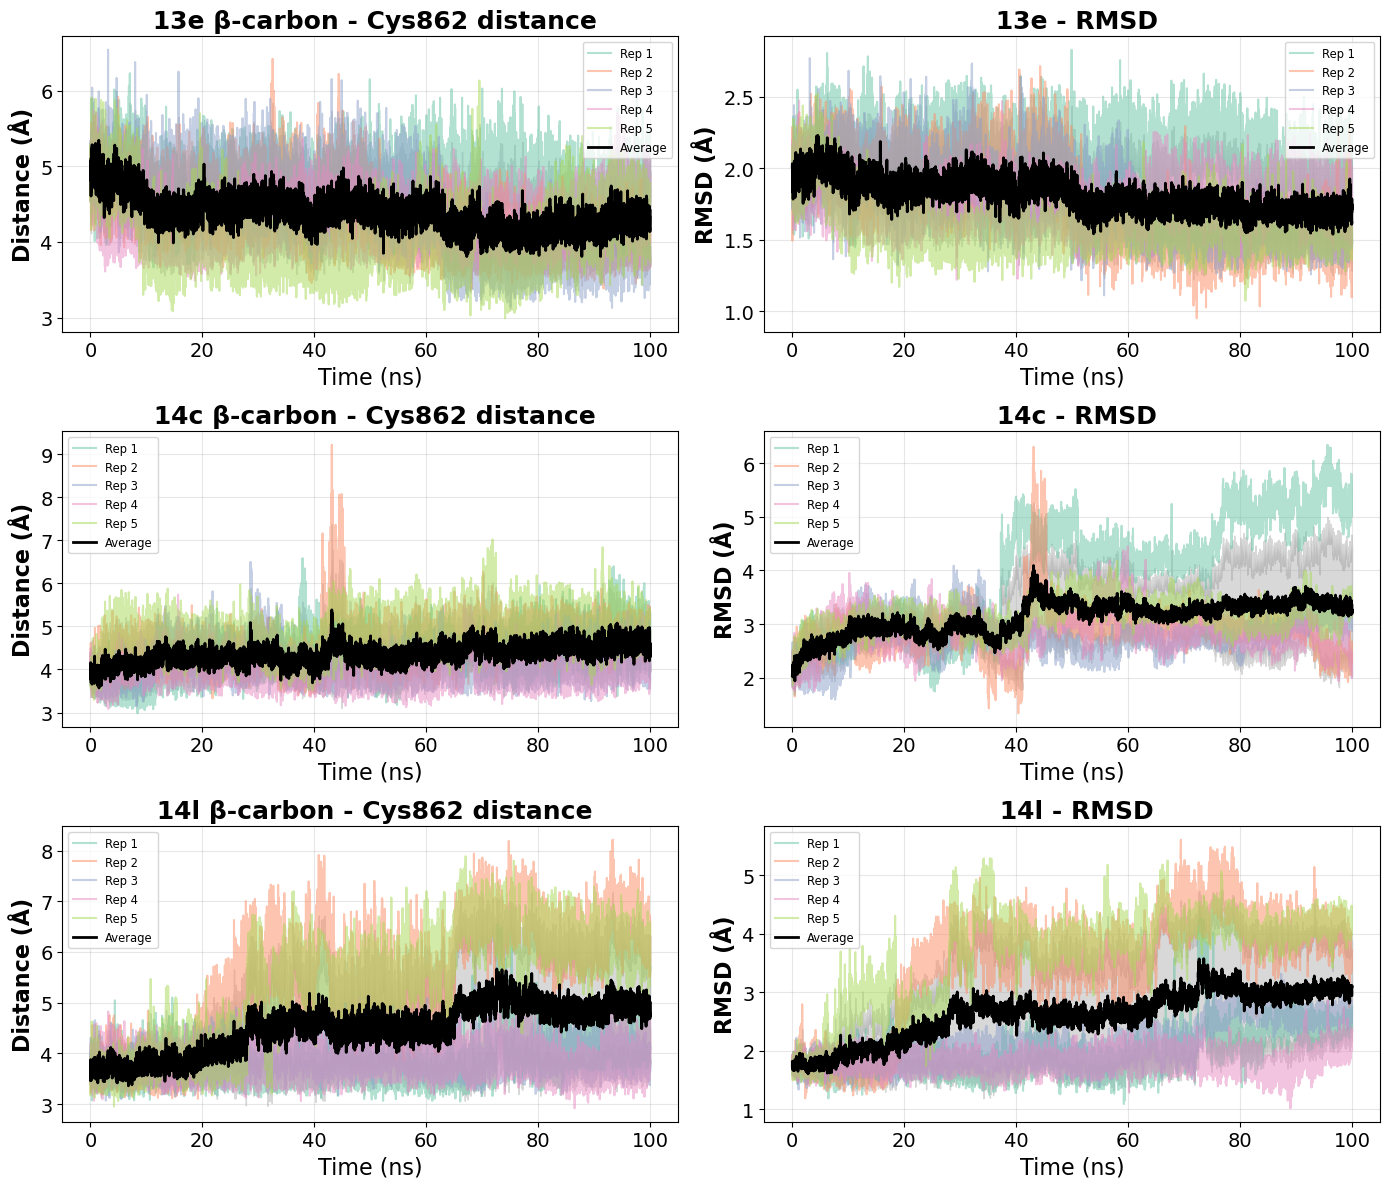


STATISTICS SUMMARY - Distance and RMSD
System     Metric     Final (Å)    Max (Å)      Min (Å)     
------------------------------------------------------------------------------------------
13e        Distance         4.42         5.35         3.81
           RMSD             1.70         2.23         1.54
------------------------------------------------------------------------------------------
14c        Distance         4.31         5.38         3.57
           RMSD             3.23         4.09         1.94
------------------------------------------------------------------------------------------
14l        Distance         4.77         5.66         3.36
           RMSD             3.10         3.58         1.60
------------------------------------------------------------------------------------------

Statistics saved to: ./md_analysis/rmsd_distance/statistics_summary.csv


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.cm import get_cmap
import seaborn as sns


# === GENERAL CONFIGURATION ===
ns_total = 100  # Total simulation time in nanoseconds
cmap = get_cmap("Set2")

# Systems to analyze
systems = ['13e', '14c', '14l']
n_replicas = 5

# Base directory for analysis files
base_dir = './md_analysis/rmsd_distance'

# === CREATE 3x2 FIGURE ===
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
final_rmsd_values = {}
final_dist_values = {}
max_rmsd_values = {}
min_rmsd_values = {}
max_dist_values = {}
min_dist_values = {}

for idx, system in enumerate(systems):
    # === DISTANCES ===
    dist_data = []
    time_array = None
    
    for rep in range(1, n_replicas + 1):
        file_path = f"{base_dir}/{system}_rep{rep}_dist.dat"
        
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found")
            continue
        
        df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=['Frame', 'Distance'])
        
        # Create time array based on actual number of frames
        if time_array is None:
            n_frames = len(df)
            time_array = np.linspace(0, ns_total, n_frames)
        
        dist_data.append(df['Distance'].values)
        axs[idx, 0].plot(time_array, df['Distance'], color=cmap(rep-1), alpha=0.5, label=f"Rep {rep}")
    
    if dist_data:
        dist_array = np.array(dist_data)
        mean_dist = np.mean(dist_array, axis=0)
        std_dist = np.std(dist_array, axis=0)
        final_dist_values[system] = mean_dist[-1]
        max_dist_values[system] = np.max(mean_dist)
        min_dist_values[system] = np.min(mean_dist)
        axs[idx, 0].plot(time_array, mean_dist, color='black', linewidth=2, label="Average")
        axs[idx, 0].fill_between(time_array, mean_dist - std_dist, mean_dist + std_dist, 
                                  color='gray', alpha=0.3)

    axs[idx, 0].set_ylabel("Distance (Å)", fontsize=16, fontweight='bold')
    axs[idx, 0].set_xlabel("Time (ns)", fontsize=16)
    axs[idx, 0].set_title(f" {system} β-carbon - Cys862 distance", fontsize=18, fontweight='bold')
    axs[idx, 0].tick_params(axis='both', labelsize=14)
    axs[idx, 0].legend(fontsize='small', loc='best')
    axs[idx, 0].grid(alpha=0.3)

    # === RMSD ===
    rmsd_data = []
    time_array_rmsd = None
    
    for rep in range(1, n_replicas + 1):
        file_path = f"{base_dir}/{system}_rep{rep}_ligand_rmsd.dat"
        
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} not found")
            continue
        
        df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=['Frame', 'RMSD'])
        
        # Create time array based on actual number of frames
        if time_array_rmsd is None:
            n_frames = len(df)
            time_array_rmsd = np.linspace(0, ns_total, n_frames)
        
        rmsd_data.append(df['RMSD'].values)
        axs[idx, 1].plot(time_array_rmsd, df['RMSD'], color=cmap(rep-1), alpha=0.5, label=f"Rep {rep}")
    
    if rmsd_data:
        rmsd_array = np.array(rmsd_data)
        mean_rmsd = np.mean(rmsd_array, axis=0)
        std_rmsd = np.std(rmsd_array, axis=0)
        final_rmsd_values[system] = mean_rmsd[-1]
        max_rmsd_values[system] = np.max(mean_rmsd)
        min_rmsd_values[system] = np.min(mean_rmsd)
        axs[idx, 1].plot(time_array_rmsd, mean_rmsd, color='black', linewidth=2, label="Average")
        axs[idx, 1].fill_between(time_array_rmsd, mean_rmsd - std_rmsd, mean_rmsd + std_rmsd, 
                                  color='gray', alpha=0.3)
    axs[idx, 1].set_ylabel("RMSD (Å)", fontsize=16, fontweight='bold')
    axs[idx, 1].set_xlabel("Time (ns)", fontsize=16)
    axs[idx, 1].set_title(f" {system} - RMSD", fontsize=18, fontweight='bold')
    axs[idx, 1].tick_params(axis='both', labelsize=14)
    axs[idx, 1].legend(fontsize='small', loc='best')
    axs[idx, 1].grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("./md_analysis/distance_rmsd_combined.png", dpi=300, bbox_inches='tight')
plt.show()

# Export detailed statistics
summary_df = pd.DataFrame({
    'Distance_Final': final_dist_values,
    'Distance_Max': max_dist_values,
    'Distance_Min': min_dist_values,
    'RMSD_Final': final_rmsd_values,
    'RMSD_Max': max_rmsd_values,
    'RMSD_Min': min_rmsd_values
})
summary_df.to_csv("./md_analysis/rmsd_distance/statistics_summary.csv")

print("\n" + "="*90)
print("STATISTICS SUMMARY - Distance and RMSD")
print("="*90)
print(f"{'System':<10} {'Metric':<10} {'Final (Å)':<12} {'Max (Å)':<12} {'Min (Å)':<12}")
print("-"*90)
for system in systems:
    # Distance stats
    dist_final = final_dist_values.get(system, np.nan)
    dist_max = max_dist_values.get(system, np.nan)
    dist_min = min_dist_values.get(system, np.nan)
    print(f"{system:<10} {'Distance':<10} {dist_final:>10.2f}   {dist_max:>10.2f}   {dist_min:>10.2f}")
    
    # RMSD stats
    rmsd_final = final_rmsd_values.get(system, np.nan)
    rmsd_max = max_rmsd_values.get(system, np.nan)
    rmsd_min = min_rmsd_values.get(system, np.nan)
    print(f"{'':<10} {'RMSD':<10} {rmsd_final:>10.2f}   {rmsd_max:>10.2f}   {rmsd_min:>10.2f}")
    print("-"*90)
print("="*90)

print(f"\nStatistics saved to: ./md_analysis/rmsd_distance/statistics_summary.csv")

## 4.2 Contacts and Hydrogen Bonds

This section analyzes molecular interactions between chalcones and protein residues:

- **Hydrophobic Contacts**: Residues with contact frequency > 70%
- **Hydrogen Bonds**: H-bonds with frequency > 10%

Heatmaps show interaction frequency across all replicas for each system.

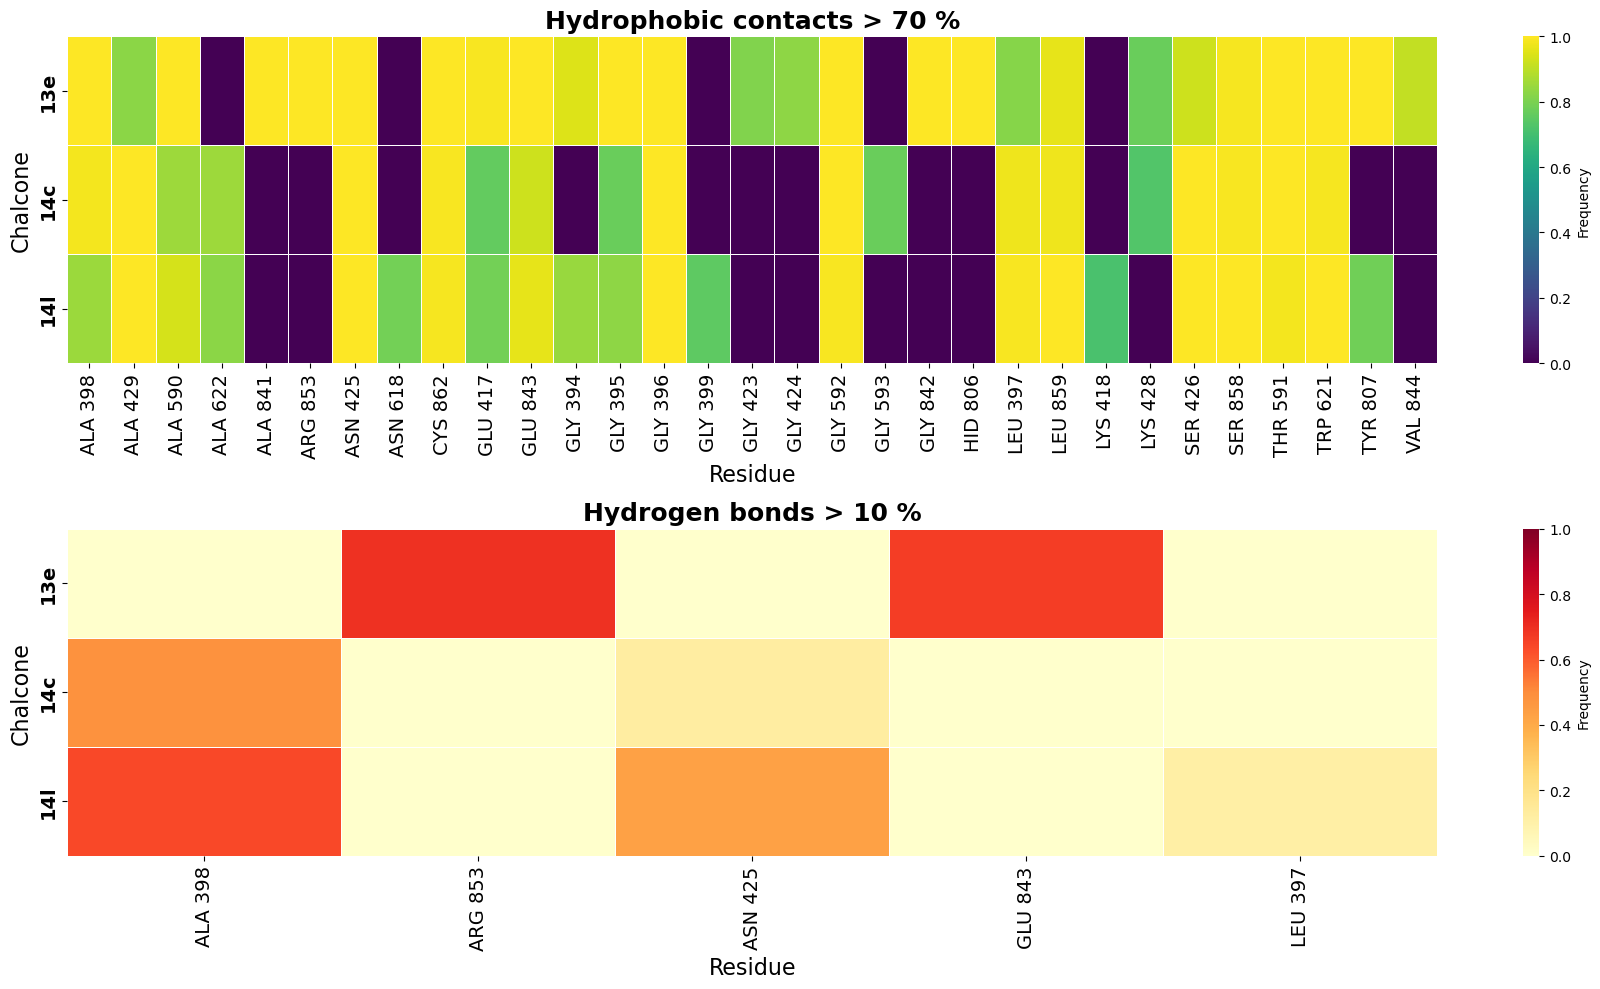


INTERACTION SUMMARY - Hydrophobic Contacts & Hydrogen Bonds

13E:
--------------------------------------------------------------------------------
  Hydrophobic Contacts:
    • Total residues involved: 26
    • Average frequency: 0.953
    • Top 3 contacts:
      - GLY396: 1.000
      - ALA398: 1.000
      - ASN425: 1.000
  Hydrogen Bonds:
    • Total residues involved: 2
    • Average frequency: 0.680
    • H-bond residues:
      - ARG853: 0.695 (±0.460)
      - GLU843: 0.665 (±0.472)

14C:
--------------------------------------------------------------------------------
  Hydrophobic Contacts:
    • Total residues involved: 19
    • Average frequency: 0.924
    • Top 3 contacts:
      - ASN425: 1.000
      - SER426: 1.000
      - THR591: 0.999
  Hydrogen Bonds:
    • Total residues involved: 2
    • Average frequency: 0.303
    • H-bond residues:
      - ALA398: 0.483 (±0.500)
      - ASN425: 0.123 (±0.328)

14L:
-----------------------------------------------------------------------

In [11]:

# Load CSV files
hbonds_df = pd.read_csv('./md_analysis/hbonds/all_systems_hbonds_ligand.csv')
contacts_df = pd.read_csv('./md_analysis/contacts/all_systems_contacts.csv')

# Function to create frequency matrix for heatmap
def create_heatmap_matrix(df):
    """
    Convert long-format dataframe to matrix format for heatmap
    Rows: chalcones, Columns: residues
    """
    # Create residue labels
    df['residue_label'] = df['residue'] + ' ' + df['residue_num'].astype(str)
    
    # Pivot table to create matrix
    matrix = df.pivot(index='chalcone', columns='residue_label', values='frecuency')
    
    # Fill NaN with 0 (residues not present in that chalcone)
    matrix = matrix.fillna(0)
    
    return matrix

# Create matrices for both heatmaps
contacts_matrix = create_heatmap_matrix(contacts_df)
hbonds_matrix = create_heatmap_matrix(hbonds_df)

# Create 2x1 subplot
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# === TOP: Hydrophobic Contacts Heatmap ===
sns.heatmap(contacts_matrix, cmap="viridis", linewidths=0.5, 
            cbar_kws={'label': 'Frequency'}, ax=axes[0],
            vmin=0, vmax=1)
axes[0].set_title("Hydrophobic contacts > 70 %", fontsize=18, fontweight='bold')
axes[0].set_xlabel("Residue", fontsize=16)
axes[0].set_ylabel("Chalcone", fontsize=16)
axes[0].tick_params(axis='x', rotation=90, labelsize=14)
axes[0].tick_params(axis='y', labelsize=14)
for label in axes[0].get_yticklabels():
    label.set_fontweight('bold')

# === BOTTOM: Hydrogen Bonds Heatmap ===
sns.heatmap(hbonds_matrix, cmap="YlOrRd", linewidths=0.5, 
            cbar_kws={'label': 'Frequency'}, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title("Hydrogen bonds > 10 %", fontsize=18, fontweight='bold')
axes[1].set_xlabel("Residue", fontsize=16)
axes[1].set_ylabel("Chalcone", fontsize=16)
axes[1].tick_params(axis='x', rotation=90, labelsize=14)
axes[1].tick_params(axis='y', labelsize=14)
for label in axes[1].get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
#plt.savefig("./md_analysis/heatmap_contacts_hbonds.png", dpi=300, bbox_inches='tight')
plt.show()

# === SUMMARY STATISTICS ===
print("\n" + "="*80)
print("INTERACTION SUMMARY - Hydrophobic Contacts & Hydrogen Bonds")
print("="*80)

for chalcone in ['13e', '14c', '14l']:
    print(f"\n{chalcone.upper()}:")
    print("-" * 80)
    
    # Contacts summary
    contacts_chalcone = contacts_df[contacts_df['chalcone'] == chalcone]
    n_contacts = len(contacts_chalcone)
    mean_freq_contacts = contacts_chalcone['frecuency'].mean()
    top_contacts = contacts_chalcone.nlargest(3, 'frecuency')[['residue', 'residue_num', 'frecuency']]
    
    print(f"  Hydrophobic Contacts:")
    print(f"    • Total residues involved: {n_contacts}")
    print(f"    • Average frequency: {mean_freq_contacts:.3f}")
    print(f"    • Top 3 contacts:")
    for idx, row in top_contacts.iterrows():
        print(f"      - {row['residue']}{int(row['residue_num'])}: {row['frecuency']:.3f}")
    
    # H-bonds summary
    hbonds_chalcone = hbonds_df[hbonds_df['chalcone'] == chalcone]
    n_hbonds = len(hbonds_chalcone)
    
    if n_hbonds > 0:
        mean_freq_hbonds = hbonds_chalcone['frecuency'].mean()
        print(f"  Hydrogen Bonds:")
        print(f"    • Total residues involved: {n_hbonds}")
        print(f"    • Average frequency: {mean_freq_hbonds:.3f}")
        print(f"    • H-bond residues:")
        for idx, row in hbonds_chalcone.iterrows():
            print(f"      - {row['residue']}{int(row['residue_num'])}: {row['frecuency']:.3f} (±{row['std_dev']:.3f})")
    else:
        print(f"  Hydrogen Bonds: None detected")


## 4.3 Final Summary

### Key Findings from MD Simulations (100 ns, 5 replicas per system)



In [16]:

# Load all analysis results
rmsd_dist_df = pd.read_csv('./md_analysis/rmsd_distance/statistics_summary.csv', index_col=0)
hbonds_df = pd.read_csv('./md_analysis/hbonds/all_systems_hbonds_ligand.csv')
contacts_df = pd.read_csv('./md_analysis/contacts/all_systems_contacts.csv')

# Create comprehensive summary
print("\n" + "="*100)
print("COMPREHENSIVE MD ANALYSIS SUMMARY")
print("="*100)
print(f"{'Simulation Parameters:':<30} 100 ns per replica, 5 replicas per system")
print(f"{'Systems analyzed:':<30} 13e, 14c, 14l")
print("="*100)

# System-by-system summary
for system in ['13e', '14c', '14l']:
    print(f"\n{'='*100}")
    print(f"SYSTEM: {system.upper()}")
    print('='*100)
    
    # === STRUCTURAL STABILITY ===
    print(f"\n{'STRUCTURAL STABILITY':^100}")
    print('-'*100)
    
    # Distance metrics
    dist_final = rmsd_dist_df.loc[system, 'Distance_Final']
    dist_max = rmsd_dist_df.loc[system, 'Distance_Max']
    dist_min = rmsd_dist_df.loc[system, 'Distance_Min']
    
    print(f"  Distance to Cys862:")
    print(f"    Final: {dist_final:>6.2f} Å  |  Max: {dist_max:>6.2f} Å  |  Min: {dist_min:>6.2f} Å")
    
    # RMSD metrics
    rmsd_final = rmsd_dist_df.loc[system, 'RMSD_Final']
    rmsd_max = rmsd_dist_df.loc[system, 'RMSD_Max']
    rmsd_min = rmsd_dist_df.loc[system, 'RMSD_Min']
    
    print(f"  Ligand RMSD:")
    print(f"    Final: {rmsd_final:>6.2f} Å  |  Max: {rmsd_max:>6.2f} Å  |  Min: {rmsd_min:>6.2f} Å")
    
    # === MOLECULAR INTERACTIONS ===
    print(f"\n{'MOLECULAR INTERACTIONS':^100}")
    print('-'*100)
    
    # Hydrophobic contacts
    contacts_sys = contacts_df[contacts_df['chalcone'] == system]
    n_contacts = len(contacts_sys)
    mean_freq_contacts = contacts_sys['frecuency'].mean()
    top_contacts = contacts_sys.nlargest(3, 'frecuency')
    
    print(f"  Hydrophobic Contacts (>70%):")
    print(f"    Total residues: {n_contacts}  |  Average frequency: {mean_freq_contacts:.3f}")
    print(f"    Top 3 residues:")
    for idx, row in top_contacts.iterrows():
        print(f"      • {row['residue']}{int(row['residue_num'])}: {row['frecuency']:.3f}")
    
    # Hydrogen bonds
    hbonds_sys = hbonds_df[hbonds_df['chalcone'] == system]
    n_hbonds = len(hbonds_sys)
    
    if n_hbonds > 0:
        mean_freq_hbonds = hbonds_sys['frecuency'].mean()
        max_freq_hbond = hbonds_sys['frecuency'].max()
        top_hbond = hbonds_sys.loc[hbonds_sys['frecuency'].idxmax()]
        
        print(f"\n  Hydrogen Bonds (>10%):")
        print(f"    Total residues: {n_hbonds}  |  Average frequency: {mean_freq_hbonds:.3f}")
        print(f"    Strongest H-bond: {top_hbond['residue']}{int(top_hbond['residue_num'])} ({max_freq_hbond:.3f})")
        print(f"    All H-bond residues:")
        for idx, row in hbonds_sys.iterrows():
            print(f"      • {row['residue']}{int(row['residue_num'])}: {row['frecuency']:.3f} (±{row['std_dev']:.3f})")
    else:
        print(f"\n  Hydrogen Bonds (>10%): None detected")

# === COMPARATIVE SUMMARY TABLE ===
print(f"\n\n{'='*100}")
print(f"{'COMPARATIVE SUMMARY TABLE':^100}")
print('='*100)

# Create summary table
summary_data = []
for system in ['13e', '14c', '14l']:
    contacts_sys = contacts_df[contacts_df['chalcone'] == system]
    hbonds_sys = hbonds_df[hbonds_df['chalcone'] == system]
    
    summary_data.append({
        'System': system.upper(),
        'RMSD_Final': rmsd_dist_df.loc[system, 'RMSD_Final'],
        'Distance_Final': rmsd_dist_df.loc[system, 'Distance_Final'],
        'N_Contacts': len(contacts_sys),
        'Avg_Contact_Freq': contacts_sys['frecuency'].mean(),
        'N_HBonds': len(hbonds_sys),
        'Avg_HBond_Freq': hbonds_sys['frecuency'].mean() if len(hbonds_sys) > 0 else 0.0
    })

summary_table = pd.DataFrame(summary_data)
print(f"\n{summary_table.to_string(index=False)}")

print("\n" + "="*100)
print("Analysis complete. Results saved to ./md_analysis/")
print("="*100)




COMPREHENSIVE MD ANALYSIS SUMMARY
Simulation Parameters:         100 ns per replica, 5 replicas per system
Systems analyzed:              13e, 14c, 14l

SYSTEM: 13E

                                        STRUCTURAL STABILITY                                        
----------------------------------------------------------------------------------------------------
  Distance to Cys862:
    Final:   4.42 Å  |  Max:   5.35 Å  |  Min:   3.81 Å
  Ligand RMSD:
    Final:   1.70 Å  |  Max:   2.23 Å  |  Min:   1.54 Å

                                       MOLECULAR INTERACTIONS                                       
----------------------------------------------------------------------------------------------------
  Hydrophobic Contacts (>70%):
    Total residues: 26  |  Average frequency: 0.953
    Top 3 residues:
      • GLY396: 1.000
      • ALA398: 1.000
      • ASN425: 1.000

  Hydrogen Bonds (>10%):
    Total residues: 2  |  Average frequency: 0.680
    Strongest H-bond: ARG853 (0.6